Using device: cpu
dx = 0.2007 , Nx = 300


Loaded data with 1 samples.
Loaded data with 1 samples.


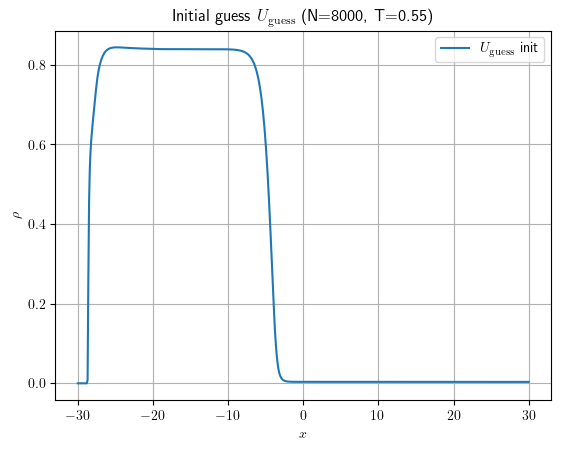

Initialized guess for the training set:                                                          rho  \
N    T                                                         
8000 0.55  [[tensor(0.), tensor(0.), tensor(0.), tensor(0...   

                                                           x  
N    T                                                        
8000 0.55  [tensor(-30.), tensor(-29.7993), tensor(-29.59...  
Wrote U_guess init figure(s) under /Users/emonti/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Code/github/cdft_lab/src/../output/plot_train/rho


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import time
import copy
from tqdm import tqdm

import torch

from libs.cdft_1d.augmented_lda import CDFT_MODEL as CDFT
from libs.cdft_1d.external_potentials import LJ126, LJ93, LJ71, HW
from libs.solve_1d.continuation_gpu import continuation
from libs.solve_1d.picard import picard
from libs.solve_1d.newton import newton
from libs.solve_1d.adjoint import adjoint

from libs.ml.surrogates import setDNN, setDNNRep, setWDA
from libs.ml.dataset_pd import setDatasetObject
from libs.ml.loss import LossL1, LossL2, SpectralLoss
from libs.utils import *
from libs.io_utils import load_pickle, DataNotFoundError

import matplotlib.pyplot as plt
plt.rcParams["text.usetex"] = True

import os
# Compute backend: "auto" | "cuda" | "mps" | "cpu". Override: export TORCH_DEVICE=mps
DEVICE_KIND = "cpu"
device = resolve_training_device(DEVICE_KIND)
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    print("Available CUDA devices:", torch.cuda.device_count())
print(f"Using device: {device}")
# Floating-point dtype for grids, parameters, and ML (torch.float64 or torch.float32).
# Apple MPS often works best with torch.float32.
TORCH_DTYPE = torch.float32
torch.manual_seed(42)  # For reproducibility


# 1 // Configuration Flags & Output Directories
_script_dir = os.path.dirname(os.path.abspath("src"))
outdir = os.path.join(_script_dir, "..", "output") + os.sep
datadir = os.path.join(_script_dir, "..", "data") + os.sep
plotdir = os.path.join(outdir, "plot_train")
plotdir_rho = os.path.join(plotdir, "rho")
os.makedirs(plotdir, exist_ok=True)
os.makedirs(plotdir_rho, exist_ok=True)

# Wall type: "wn2" or "wc" (sets pkldir and Vext params)
WALL = "wc"
if WALL == "wn2":
    pkldir = os.path.join(datadir, "dataset", "pkl", "profiles_wl_wn2") + os.sep
elif WALL == "wc":
    pkldir = os.path.join(datadir, "dataset", "pkl", "profiles_wl_wc") + os.sep
else:
    pkldir = os.path.join(datadir, "dataset", "pkl", "profiles_wl") + os.sep
# Ensure ML model and reference solution directories exist for saving
ml_dicts_dir = os.path.join(datadir, "ml_model", "ml_dicts")
ml_intermediate_dir = os.path.join(datadir, "ml_model", "intermediate_models")
os.makedirs(ml_dicts_dir, exist_ok=True)
os.makedirs(ml_intermediate_dir, exist_ok=True)
USE_MODEL = 1
USE_DBH_DIAMETER = 0  # 1: use Barker-Henderson diameter scaling when USE_MODEL
TRAIN_DNN = 1
TRAIN_DNN_REP = 1
TRAIN_WDA = 1
RESTART_ML_MODEL = 0
SAVE_MODEL = 1
SAVE_INTERMEDIATE_MODELS = 0
JACOBIAN = "EXACT"


if TRAIN_DNN or TRAIN_WDA or TRAIN_DNN_REP: JACOBIAN = "EXACT" # Must be exact for training 

# 3 // Thermodynamic parameters
R           = 1.
mu          = 1.       # mu == chemical potential if Grand Canonical cDFT // mu == particles' number if Canonical cDFT
beta        = 1/0.95
m           = 1.
dft_type    = "LDA"
ensemble    = "NVT"  #"muVT" or "NVT"
guess_coex  = [0.001, 0.9]
str_param   = "mu" if ensemble == "muVT" else "N"



# Compute Lambda
# kb          = 1.38065e-23
# unit_mass   = 1.6726e-27
# mass_star   = 39.95 * unit_mass
# eps_star    = 120.*kb
# sigma_star  = 0.34e-9
# h_star      = np.sqrt(mass_star * eps_star * sigma_star**2)
# h_p         = 6.63e-34/h_star
Lambda      = 1. #np.sqrt(h_p**2 * beta / (2*np.pi*m))



# 2 // SOLVERS: Parameter for the DFT Model solvers
newton_max_steps = 1600
newton_tol = 1e-7
newton_alpha = 0.09
newton_verbose = 0
 
cont_ds = 0.5 * (1 - 2*(ensemble=="NVT") )
cont_continuation_steps = 70
cont_max_corrector_steps = 500
cont_alpha = 1.
cont_plot = True



# 4 // Internal and external potential parameters (Ew, sigmaw depend on WALL)
sigma_attr  = 1*R
eps_attr    = 1.
cutoff_attr = 2.5 * R
if WALL == "wn2":
    Ew, sigmaw = 1.2, 1.2
elif WALL == "wc":
    Ew, sigmaw = 1., 2.
else:
    Ew, sigmaw = 1.2, 1.2
cutoff_wall = 10. * R



# 5 // Mesh: Spatial Discretization
L           = 30.
xmin, xmax  = -L, L
Nx          = int(2*L/(0.2*R))
BS          = 5
x_bc        = [xmin, xmax]
x           = torch.linspace(xmin, xmax, Nx, dtype=TORCH_DTYPE).to(device)
x_wall      = (xmin - 0.001*sigmaw)
dx          = x[1] - x[0]
print(f"dx = {dx.item():.4f} , Nx = {Nx}\n\n")


# 6 // External Potential (e.g., Hard Wall) Setup
#Vext = HW(x, x_wall, Ew, sigmaw)
Vext = (
    (LJ93(x, x_wall, Ew, sigmaw) - LJ93(cutoff_wall*torch.ones_like(x), x_wall, Ew, sigmaw)) 
    * 
    torch.sigmoid(-(x - x_wall - cutoff_wall) / (1e-3)) 
)[None,...]  # [B, 1, Nx].      # Shifted 

BC_R = "NONE"  # Right BC: NONE, ZEROGRAD, SYMM available



# 7 // MD
target_density = 0.2798



# 8 // Guess solution
rho_guess   = torch.zeros((BS, 1, Nx), dtype=TORCH_DTYPE).to(device)  # [B, 1, Nx]
#(Vext*0.) + Lambda**(-3) * torch.exp(beta*(torch.tensor(mu)))*0 # [B, 1, Nx]



# 9 // ML
lr = 1e-4
epochs = 10000
# train_T = [0.55, 0.65, 0.75, 0.85, 0.95]
train_T = [0.55, ]
good_N = [8000]



# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
eq_params = {
    "R": torch.tensor(R, dtype=TORCH_DTYPE, device=device),
    "mu": torch.tensor(mu, dtype=TORCH_DTYPE, device=device)[None, None],  # [B, 1]
    "beta": torch.tensor(beta, dtype=TORCH_DTYPE, device=device)[None, None],  # [B, 1]
    "Lambda": torch.tensor(Lambda, dtype=TORCH_DTYPE, device=device),
    "dft_type": dft_type,
    "ensemble": ensemble,
    "str_param": str_param,
    "sigma_attr": torch.tensor(sigma_attr, dtype=TORCH_DTYPE, device=device),
    "eps_attr": torch.tensor(eps_attr, dtype=TORCH_DTYPE, device=device),
    "cutoff_attr": torch.tensor(cutoff_attr, dtype=TORCH_DTYPE, device=device),
    "Ew": torch.tensor(Ew, dtype=TORCH_DTYPE, device=device),
    "sigmaw": torch.tensor(sigmaw, dtype=TORCH_DTYPE, device=device),
    "Vext": Vext,
    "BC_R": BC_R,
}

mesh = {
    "BS": BS,
    "L": L,
    "Nx": Nx,
    "x_bc": [xmin, xmax],
    "x": torch.linspace(xmin, xmax, Nx, dtype=TORCH_DTYPE).to(device),
    "x_wall": torch.tensor(x_wall, dtype=TORCH_DTYPE, device=device),
    "dx": dx.to(device),
}

sol = {
    "rho_guess": rho_guess.to(device),
    "device": device,
    "dtype": TORCH_DTYPE,
    "outdir": outdir,
    "datadir": datadir,
    "pkldir": pkldir,
    "RESTART_ML_MODEL": RESTART_ML_MODEL,
    "SAVE_MODEL": SAVE_MODEL,
    "SAVE_INTERMEDIATE_MODELS": SAVE_INTERMEDIATE_MODELS,
    "USE_MODEL": USE_MODEL,
    "USE_DBH_DIAMETER": USE_DBH_DIAMETER,
    "TRAIN_DNN": TRAIN_DNN,
    "TRAIN_DNN_REP": TRAIN_DNN_REP,
    "TRAIN_WDA": TRAIN_WDA,
    "JACOBIAN": JACOBIAN,
    "LOSS": LossL2,  # LossL2, LossL1 or SpectralLoss
}




# ------------------------------------------------------------------------------
# Instantiate CDFT Model -------------------------------------------
model = CDFT(eq_params, mesh, sol)



# ------------------------------------------------------------------------------
# Instantiate the dataset ------------------------------------------------------
data_md, dataloader_md = setDatasetObject(
                                          good_N,
                                          train_T,
                                          pkldir,
                                          mesh,
                                          sol,
                                          transform = True,
                                          batch_size = BS,
                                          batches_in_list=False,
                                          )



# ------------------------------------------------------------------------------
# Instantiate ML Models -------------------------------------------
setDNN(model, LR=lr)
setDNNRep(model, LR=lr)
setWDA(model, LR=lr, modes=150)

if not TRAIN_DNN:
    model.dnn_fn.eval()
    model.dnn_g_fn.eval()
    for param in model.dnn_fn.parameters():
        param.requires_grad = False
    for param in model.dnn_g_fn.parameters():
        param.requires_grad = False
if not TRAIN_DNN_REP:
    model.dnn_rep_fn.eval()
    for param in model.dnn_rep_fn.parameters():
        param.requires_grad = False
if not TRAIN_WDA:
    model.wda_fn.eval()
    for param in model.wda_fn.parameters():
        param.requires_grad = False



# ------------------------------------------------------------------------------
# Initialize the guess solution pandas DataFrame
if RESTART_ML_MODEL:
    U_guess_df = load_pickle(
        os.path.join(ml_dicts_dir, "U_guess.pkl"),
        description="U_guess (restart file)",
        hint="Train from scratch with RESTART_ML_MODEL=0, or ensure a previous run saved U_guess.pkl.",
    )
    U_guess_df[['rho', 'x']] = dataframe_elementwise_map(
        U_guess_df[['rho', 'x']],
        lambda arr: torch.tensor(arr, dtype=model.sol["dtype"], device=model.sol["device"]),
    )
else:
    # df_0 is initial reference MF LDA solution DataFrame with MultiIndex (N, T)
    U_guess_df = data_md.df_0.copy()[['rho', "x"]]   # Guess solution from LDA MF
    # U_guess_df = data_md.df_md.copy()[['rho', "x"]]   # Guess solution MD
    U_guess_df = U_guess_df.reset_index().set_index(['N', 'T']).sort_index()
    U_guess_df[['rho', 'x']] = dataframe_elementwise_map(
        U_guess_df[['rho', 'x']],
        lambda arr: torch.tensor(arr, dtype=model.sol["dtype"], device=model.sol["device"]),
    )

U_guess_df = normalize_profiles_nt_multiindex(U_guess_df)

for idx, row in U_guess_df.iterrows():
    x_src = row['x']                # torch tensor (Nx,)
    rho_src = row['rho'].squeeze() # torch tensor (Nx,) or (1, Nx)
    
    rho_interp = data_md.interpolate_rho(
        x_src,
        rho_src,
        model.mesh["x"],
    ).to(model.sol["device"])       # shape: (1, Nx)

    U_guess_df.at[idx, 'rho'] = rho_interp
    U_guess_df.at[idx, 'x'] = model.mesh["x"]

for idx, row in U_guess_df.iterrows():
    N_val, T_key = profile_nt_index_key(idx[0], idx[1])
    x_g = row["x"]
    rho_g = row["rho"].squeeze()
    if x_g.ndim > 1:
        x_g = x_g.flatten()
    if rho_g.ndim > 1:
        rho_g = rho_g.flatten()
    plt.figure()
    plt.plot(data_md.df_0.copy().at[(N_val, T_key), "x"], data_md.df_0.copy().at[(N_val, T_key), "rho"], color="C0", label=r"$U_{\mathrm{guess}}$ init")
    plt.xlabel(r"$x$")
    plt.ylabel(r"$\rho$")
    plt.title(rf"Initial guess $U_{{\mathrm{{guess}}}}$ (N={N_val}, T={T_key})")
    plt.legend()
    plt.grid()
    plt.show()
    plt.close()
print("Initialized guess for the training set:", U_guess_df.head())
print(f"Wrote U_guess init figure(s) under {plotdir_rho}")


def update_U_guess_df(U_guess_df, batch, new_rho):
    # new_rho: tensor of shape [B, 1, Nx]
    for i in range(new_rho.size(0)):
        N_val, T_key = profile_nt_index_key(batch['N'][i].item(), batch['T'][i].item())
        U_guess_df.at[(N_val, T_key), 'rho'] = new_rho[i, ...]

def get_rho_from_U_guess_df(U_guess_df, batch):
    rho_list = []

    for i in range(batch['rho'].shape[0]):
        N_val, T_key = profile_nt_index_key(batch['N'][i].item(), batch['T'][i].item())

        rho_val = U_guess_df.at[(N_val, T_key), 'rho']  # shape: (1, Nx) or (Nx,)
        
        # Ensure correct shape (1, Nx)
        if rho_val.ndim == 1:
            rho_val = rho_val.unsqueeze(0)

        rho_list.append(rho_val.to(batch['rho'].device))  # move to same device

    # Stack to shape: (B, 1, Nx)
    return torch.stack(rho_list, dim=0)



In [7]:
z_profiles_0_path = os.path.join(pkldir,"z_profiles_0.pkl")


df_0 = load_pickle(
    z_profiles_0_path,
    description="Reference LDA profiles (z_profiles_0.pkl)",
    hint="Run: python preprocess_data.py (or use --skip-lda for quick setup)",
)
print(df_0)


                                                         rho  \
N    T                                                         
4000 0.55  [0.0, 0.0, 0.0, 0.0, 4.3417066925829293e-216, ...   
     0.6   [0.0, 0.0, 0.0, 0.0, 5.722688304955697e-187, 1...   
     0.65  [0.0, 0.0, 0.0, 0.0, 2.9101842632182146e-239, ...   
     0.7   [0.0, 0.0, 0.0, 0.0, 2.1098155608493384e-303, ...   
     0.75  [0.0, 0.0, 0.0, 0.0, 5e-324, 5e-324, 5e-324, 5...   
     0.8   [0.0, 0.0, 0.0, 0.0, 5e-324, 5e-324, 5e-324, 5...   
     0.85  [0.0, 0.0, 0.0, 0.0, 5e-324, 5e-324, 5e-324, 5...   
     0.9   [0.0, 0.0, 0.0, 0.0, 5e-324, 5e-324, 5e-324, 5...   
     0.95  [0.0, 0.0, 0.0, 0.0, 5e-324, 5e-324, 5e-324, 5...   
     1.0   [0.0, 0.0, 0.0, 0.0, 5e-324, 5e-324, 5e-324, 5...   
5000 0.55  [0.0, 0.0, 0.0, 0.0, 3.8791726481268145e-172, ...   
     0.6   [0.0, 0.0, 0.0, 0.0, 5.314104961189609e-255, 1...   
     0.65  [0.0, 0.0, 0.0, 0.0, 1.00659035e-315, 2.023399...   
     0.7   [0.0, 0.0, 0.0, 0.0, 5e-324, 

In [10]:
import numpy as np

def _to_numpy_1d(x):
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy().astype(np.float64, copy=False).reshape(-1)
    return np.asarray(x, dtype=np.float64).reshape(-1)

x_shift = 30.0
df_0_shifted = df_0[["x", "rho"]].copy()
df_0_shifted["x"] = df_0_shifted["x"].apply(lambda x: _to_numpy_1d(x) + x_shift)
out_path = os.path.join(pkldir, "z_profiles_0.pkl")
df_0_shifted.to_pickle(out_path)
df_0 = df_0_shifted  # keep in-memory view aligned with file
print(f"Wrote x-shifted (+{x_shift:g}) reference profiles to {out_path}")

Wrote x-shifted (+30) reference profiles to /Users/emonti/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Code/github/cdft_lab/src/../data/dataset/pkl/profiles_wl_wc/z_profiles_0.pkl


[0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 4.94065646e-324 4.94065646e-324 4.94065646e-324 4.94065646e-324
 4.94065646e-324 2.36872571e-127 2.96817994e-047 1.38306827e-018
 2.01120533e-007 8.77863954e-003 2.62808168e-001 4.58635488e-001
 5.42066027e-001 5.85986170e-001 6.14868101e-001 6.37766599e-001
 6.58308250e-001 6.77947296e-001 6.97214160e-001 7.16239108e-001
 7.34809496e-001 7.51956218e-001 7.66844580e-001 7.79337299e-001
 7.89723045e-001 7.98391761e-001 8.05692618e-001 8.11898279e-001
 8.17209515e-001 8.21770622e-001 8.25684939e-001 8.29028117e-001
 8.31859840e-001 8.34232584e-001 8.36195849e-001 8.37798742e-001
 8.39117075e-001 8.40208650e-001 8.41109871e-001 8.41848191e-001
 8.42446138e-001 8.42922976e-001 8.43295545e-001 8.43578761e-001
 8.43785950e-001 8.43929055e-001 8.44018744e-001 8.44064328e-001
 8.44073717e-001 8.44053528e-001 8.44009283e-001 8.43945605e-001
 8.43866386e-001 8.43774910e-001 8.43673965e-001 8.43565909e-001
 8.43452737e-001 8.433361

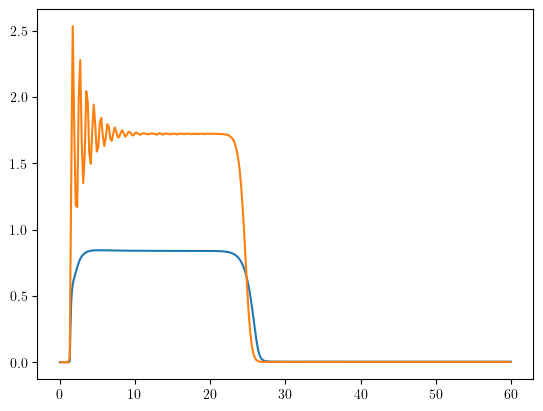

In [13]:
print(df_0_shifted.at[(8000, 0.55), "rho"])
plt.plot(df_0_shifted.at[(8000, 0.55), "x"], df_0_shifted.at[(8000, 0.55), "rho"])
print(data_md.df_md.at[(8000, 0.55), "rho"])
plt.plot(data_md.df_md.at[(8000, 0.55), "x"], data_md.df_md.at[(8000, 0.55), "rho"])

In [9]:
data_md.df_0

,,rho,x
N,T,,
8000,0.55,"[0.0, 0.0, 0.0, 0.0, 5e-324, 5e-324, 5e-324, 5...","[-30.0, -29.89983305509182, -29.79966611018364..."


In [ ]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import torch

from libs.cdft_1d.augmented_lda import CDFT_MODEL as CDFT
from libs.cdft_1d.external_potentials import LJ93
from libs.ml.surrogates import setDNN, setWDA, setDNNRep, load_ml_state_dicts
from libs.ml.loss import LossL1
from libs.utils import resolve_training_device, sol_dtype, tensors_to_cpu_for_storage


def update_model(x_, rho_, T_, mesh_=None, sol_=None, ml_state_dicts_=None):
    """Build CDFT model for given mesh and temperature.
    If mesh_ and sol_ are provided (e.g. mesh_bulk, sol_bulk), use them for efficient bulk (0D) computations.
    """
    if mesh_ is not None and sol_ is not None:
        mesh_local = mesh_
        sol_local = sol_
    else:
        mesh_local = {
            "BS": 1,
            "L": x_.max().item(),
            "Nx": len(x_),
            "x_bc": [x_.min().item(), x_.max().item()],
            "x": x_,
            "x_wall": x_.min() - 0.001,
            "dx": (x_[1] - x_[0]).to(device),
        }
        sol_local = sol
    eq_params_local = dict(eq_params)
    td = sol_dtype(sol_local)
    eq_params_local["beta"] = torch.tensor(1 / T_, dtype=td, device=device)[None, None]
    eq_params_local["mu"] = rho_.sum(-1) * mesh_local["dx"]
    eq_params_local["Vext"] = LJ93(mesh_local["x"], mesh_local["x_wall"], 1, 2)[None, ...].to(device) * 0
    model = CDFT(eq_params_local, mesh_local, sol_local)
    sd = ml_state_dicts_ if ml_state_dicts_ is not None else None
    setDNN(model, LR=0.0, state_dicts=sd)
    setDNNRep(model, LR=0.0, state_dict=sd["dnn_rep_fn"] if sd else None)
    setWDA(model, LR=0.0, modes=150, state_dict=sd["wda_fn"] if sd else None)
    return model


def chem_pot(rho, model):
    """Bulk chemical potential."""
    beta = model.eq_params["beta"][..., None]
    Lambda = model.eq_params["Lambda"]
    DF = model.gradients_FX(rho, detach_tensors=True, compute_D2FX=False)["DF"]
    mu = 1 / beta * (torch.log(Lambda**3 * rho)) + DF
    return mu


def coex_equations_auto(rho_vec, model):
    """Returns [eq1, eq2] enforcing mu(rho1)=mu(rho2) and P(rho1)=P(rho2)."""
    r1, r2 = rho_vec
    R1 = r1 * torch.ones_like(model.sol["rho_guess"])
    R2 = r2 * torch.ones_like(model.sol["rho_guess"])
    mu1 = model.GetChemPot(R1.sum() * model.mesh["dx"], R1).squeeze()
    mu2 = model.GetChemPot(R2.sum() * model.mesh["dx"], R2).squeeze()
    p1 = -model.GetOmega(R1)[0][0, 0, R1.shape[-1] // 2]
    p2 = -model.GetOmega(R2)[0][0, 0, R2.shape[-1] // 2]
    return [mu1 - mu2, p1 - p2]


def solve_newton(coex_equations, rho_init, model, tol=1e-5, max_iter=1000, alpha=0.3, verbose=True):
    """Newton-Raphson for coexistence equations."""
    rho0 = rho_init.clone().detach().to(model.sol["device"])
    for i in range(max_iter):
        rho0.requires_grad_(True)
        rho = rho0
        F = coex_equations(rho, model)
        td = sol_dtype(model.sol)
        J = torch.zeros((2, 2), dtype=td, device=rho.device)
        for j in range(2):
            J_i = torch.autograd.grad(
                F[j], rho, retain_graph=True, materialize_grads=True
            )[0]
            J[j, :] = J_i
        F_n = torch.tensor([F[0].item(), F[1].item()], dtype=td, device=rho.device)
        with torch.no_grad():
            delta_rho = torch.linalg.solve(J, -F_n)
            rho0.add_(alpha * delta_rho)
        if verbose and i % 10 == 0:
            print(i, delta_rho.norm().item(), rho0)
        if torch.norm(delta_rho).item() < tol:
            if verbose:
                print("Number of Newton iterations:", i + 1)
            break
    return rho0.detach()


def newton_critical_point(
    eq_params, mesh, sol, rho0, T0, max_iter=20, tol=1e-8, alpha=1., device=None, ml_state_dicts_=None
):
    """Solve for (rho_c, T_c) such that ∂p/∂rho=0 and ∂²p/∂rho²=0."""
    if device is None:
        device = sol["device"]
    device = torch.device(device)
    td = sol_dtype(sol)
    rho = torch.tensor(float(rho0), dtype=td, device=device)
    T = torch.tensor(float(T0), dtype=td, device=device)
    # Vext matching mesh (zero for bulk)
    Vext_mesh = LJ93(mesh["x"], mesh["x_wall"], 1, 2)[None, ...].to(device) * 0
    for it in range(max_iter):
        rho_var = rho.clone().detach().requires_grad_(True)
        T_var = T.clone().detach().requires_grad_(True)
        beta = 1.0 / T_var
        eq_params_local = dict(eq_params)
        eq_params_local["beta"] = beta * torch.ones_like(eq_params_local["mu"], dtype=td)
        eq_params_local["Vext"] = Vext_mesh
        model = CDFT(eq_params_local, mesh, sol)
        sd = ml_state_dicts_
        setDNN(model, LR=0.0, state_dicts=sd)
        setDNNRep(model, LR=0.0, state_dict=sd["dnn_rep_fn"] if sd else None)
        setWDA(model, LR=0.0, modes=150, state_dict=sd["wda_fn"] if sd else None)
        model.dnn_fn.eval()
        model.dnn_rep_fn.eval()
        model.wda_fn.eval()
        R1 = rho_var * torch.ones_like(model.sol["rho_guess"])
        omega = model.GetOmega(R1)[0]
        Nx = omega.shape[-1]
        p = -omega[0, 0, Nx // 2]
        p_prime = torch.autograd.grad(p, rho_var, create_graph=True)[0]
        p_second = torch.autograd.grad(p_prime, rho_var, create_graph=True)[0]
        f1, f2 = p_prime, p_second
        F = torch.stack([f1, f2])
        if F.norm().item() < tol:
            print(f"Converged in {it} iterations (function norm).")
            break
        df1_drho = torch.autograd.grad(f1, rho_var, retain_graph=True)[0]
        df1_dT = torch.autograd.grad(f1, T_var, retain_graph=True)[0]
        df2_drho = torch.autograd.grad(f2, rho_var, retain_graph=True)[0]
        df2_dT = torch.autograd.grad(f2, T_var)[0]
        J = torch.stack([torch.stack([df1_drho, df1_dT]), torch.stack([df2_drho, df2_dT])])
        delta = torch.linalg.solve(J, -F)
        rho = rho + delta[0]
        T = T + delta[1]
        print("Norm:", delta.norm().item())
        if delta.norm().item() < tol:
            print(f"Converged in {it + 1} iterations (step size).")
            break
    return rho.item(), T.item()



if __name__ == "__main__":
    # ------------------------------------------------------------------------------
    # Output directory
    # ------------------------------------------------------------------------------

    script_dir = os.path.dirname(os.path.abspath("./src"))
    sys.path.insert(0, script_dir)
    output_dir = os.path.join(script_dir, "..", "output", "bulk_tmd")
    os.makedirs(output_dir, exist_ok=True)

    # ------------------------------------------------------------------------------
    # Configuration
    # ------------------------------------------------------------------------------
    outdir = os.path.join(script_dir, "..", "output") + "/"
    datadir = os.path.join(script_dir, "..", "data") + "/"
    pkldir = datadir + "dataset/pkl/profiles/"
    DEVICE_KIND = "auto"  # or "cuda" | "mps" | "cpu"; override with env TORCH_DEVICE
    device = resolve_training_device(DEVICE_KIND)
    print(f"Using device: {device}")
    TORCH_DTYPE = torch.float64
    torch.manual_seed(42)

    # Flags
    JACOBIAN = "EXACT"
    USE_MODEL = 1
    USE_DBH_DIAMETER = 0
    TRAIN_DNN = 0
    TRAIN_WDA = 0
    RESTART_ML_MODEL = 1
    SAVE_MODEL = 1
    fast = False

    # Thermodynamic parameters
    R, mu, m = 1., 1., 1.
    beta = 1 / 1.6
    dft_type = "LDA"
    ensemble = "NVT"
    guess_coex = [0.001, 0.9]
    str_param = "mu" if ensemble == "muVT" else "N"
    Lambda = 1.

    # External potential parameters
    sigma_attr = R
    eps_attr = 1.
    cutoff_attr = 2.5 * R
    Ew = 1.
    sigmaw = 1 * sigma_attr

    # Mesh (full-size, kept for compatibility with model init)
    L = 30.
    xmin, xmax = -L, L
    Nx = int(2 * L / (0.2 * R))
    x = torch.linspace(xmin, xmax, Nx, dtype=TORCH_DTYPE).to(device)
    dx = x[1] - x[0]
    x_wall = xmin - 0.01 * sigmaw
    BS = 1

    # Minimal mesh for bulk (0D problem: uniform density)
    # Exploit homogeneity: use Nx=3 (minimal for FFT), output is uniform everywhere.
    # Attractive uses fixed r_grid for integral; WDA supports small grids via BULK_COMP.
    Nx_bulk = 3
    L_bulk = 0.2 * R * (Nx_bulk - 1) / 2  # symmetric around 0
    x_bulk = torch.linspace(-L_bulk, L_bulk, Nx_bulk, dtype=TORCH_DTYPE).to(device)
    dx_bulk = x_bulk[1] - x_bulk[0]
    x_wall_bulk = x_bulk.min() - 0.01 * sigmaw

    # External potential and initial guess
    Vext = LJ93(x, x_wall, Ew, sigmaw)[None, ...].to(device) * 0.
    rho_guess = torch.zeros((BS, 1, Nx), dtype=TORCH_DTYPE).to(device)
    rho_guess_bulk = torch.zeros((BS, 1, Nx_bulk), dtype=TORCH_DTYPE).to(device)

    # Build parameter dicts
    eq_params = {
        "R": torch.tensor(R, dtype=TORCH_DTYPE, device=device),
        "mu": torch.tensor(mu, dtype=TORCH_DTYPE, device=device)[None, None],
        "beta": torch.tensor(beta, dtype=TORCH_DTYPE, device=device)[None, None],
        "Lambda": torch.tensor(Lambda, dtype=TORCH_DTYPE, device=device),
        "dft_type": dft_type,
        "ensemble": ensemble,
        "str_param": str_param,
        "sigma_attr": torch.tensor(sigma_attr, dtype=TORCH_DTYPE, device=device),
        "eps_attr": torch.tensor(eps_attr, dtype=TORCH_DTYPE, device=device),
        "cutoff_attr": torch.tensor(cutoff_attr, dtype=TORCH_DTYPE, device=device),
        "Ew": torch.tensor(Ew, dtype=TORCH_DTYPE, device=device),
        "sigmaw": torch.tensor(sigmaw, dtype=TORCH_DTYPE, device=device),
        "Vext": Vext,
        "BC_R": "NONE",
        "fast": fast,
    }

    mesh = {
        "BS": BS,
        "L": L,
        "Nx": Nx,
        "x_bc": [xmin, xmax],
        "x": x,
        "x_wall": torch.tensor(x_wall, dtype=TORCH_DTYPE, device=device),
        "dx": dx.to(device),
    }

    mesh_bulk = {
        "BS": BS,
        "L": L_bulk,
        "Nx": Nx_bulk,
        "x_bc": [x_bulk.min().item(), x_bulk.max().item()],
        "x": x_bulk,
        "x_wall": x_wall_bulk.to(device=device, dtype=TORCH_DTYPE)
        if torch.is_tensor(x_wall_bulk)
        else torch.tensor(x_wall_bulk, dtype=TORCH_DTYPE, device=device),
        "dx": dx_bulk.to(device),
        "BULK_COMP": True,  # 0D bulk: WDA supports small grids
    }

    sol = {
        "rho_guess": rho_guess,
        "device": device,
        "dtype": TORCH_DTYPE,
        "outdir": outdir,
        "datadir": datadir,
        "pkldir": pkldir,
        "JACOBIAN": JACOBIAN,
        "RESTART_ML_MODEL": RESTART_ML_MODEL,
        "SAVE_MODEL": SAVE_MODEL,
        "USE_MODEL": USE_MODEL,
        "USE_DBH_DIAMETER": USE_DBH_DIAMETER,
        "TRAIN_DNN": TRAIN_DNN,
        "TRAIN_WDA": TRAIN_WDA,
        "LOSS": LossL1,
    }

    # sol_bulk: same as sol but with minimal rho_guess for bulk (0D) computations
    sol_bulk = {**sol, "rho_guess": rho_guess_bulk}

    # Load ML state dicts once to avoid repeated disk I/O in coexistence/critical-point loops
    ml_state_dicts = load_ml_state_dicts(datadir, device) if RESTART_ML_MODEL else None

    model = CDFT(eq_params, mesh, sol)
    sd = ml_state_dicts
    setDNN(model, LR=0, state_dicts=sd)
    setDNNRep(model, LR=0, state_dict=sd["dnn_rep_fn"] if sd else None)
    setWDA(model, LR=0, modes=150, state_dict=sd["wda_fn"] if sd else None)

    # Critical point NN (bulk mesh with BULK_COMP for efficiency)
    sol_bulk["USE_MODEL"] = True
    rho_c_guess, T_c_guess = 0.3190, 1.0779
    rho_c_nn, T_c_nn = newton_critical_point(
        eq_params, mesh_bulk, sol_bulk, rho_c_guess, T_c_guess,
        max_iter=150, tol=1e-9, alpha=1., device=device, ml_state_dicts_=ml_state_dicts
    )
    print("Critical point (NN):")
    print("rho_c =", rho_c_nn)
    print("T_c   =", T_c_nn)

    # Critical point MF (USE_MODEL=False)
    sol_bulk["USE_MODEL"] = False
    rho_c_guess_mf, T_c_guess_mf = 0.08, 0.95  # MF/LDA critical point is at lower rho, T
    rho_c_mf, T_c_mf = newton_critical_point(
        eq_params, mesh_bulk, sol_bulk, rho_c_guess_mf, T_c_guess_mf,
        max_iter=150, tol=1e-9, alpha=1., device=device, ml_state_dicts_=None
    )
    print("Critical point (MF):")
    print("rho_c =", rho_c_mf)
    print("T_c   =", T_c_mf)

    # Restore USE_MODEL for coexistence loops
    sol_bulk["USE_MODEL"] = True

    # Coexistence with neural model (USE_MODEL=True) - bulk mesh with BULK_COMP
    T_list = [0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 1.0]
    rho_l_l, rho_v_l = [], []
    for T_val in T_list:
        model = update_model(x_=mesh_bulk["x"], rho_=rho_guess_bulk, T_=T_val, mesh_=mesh_bulk, sol_=sol_bulk, ml_state_dicts_=ml_state_dicts)
        model.sol["USE_MODEL"] = True
        print(f"T={1/model.eq_params['beta'].item():.2f}")
        rho_v, rho_l = solve_newton(
            coex_equations_auto,
            rho_init=torch.tensor([1e-15, 1 - 1e-15], dtype=TORCH_DTYPE, device=device),
            model=model,
            tol=1e-4,
            max_iter=100000,
            alpha=0.1,
            verbose=1,
        )
        print(f"rho_v = {rho_v.item()}, rho_l = {rho_l.item()}")
        rho_v_l.append(rho_v), rho_l_l.append(rho_l)

    # Coexistence without neural model (USE_MODEL=False) - use minimal bulk mesh for ~35x speedup
    T_list0 = [0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 1.0]
    rho_l_l0, rho_v_l0 = [], []
    for T_val in T_list0:
        model = update_model(x_=mesh_bulk["x"], rho_=rho_guess_bulk, T_=T_val, mesh_=mesh_bulk, sol_=sol_bulk, ml_state_dicts_=ml_state_dicts)
        model.sol["USE_MODEL"] = False
        print(f"T={1/model.eq_params['beta'].item():.2f} (MF)")
        rho_v, rho_l = solve_newton(
            coex_equations_auto,
            rho_init=torch.tensor([1e-15, 1 - 1e-15], dtype=TORCH_DTYPE, device=device),
            model=model,
            tol=1e-6,
            max_iter=1000,
            alpha=0.05,
            verbose=False,
        )
        print(f"rho_v = {rho_v.item()}, rho_l = {rho_l.item()}")
        rho_v_l0.append(rho_v), rho_l_l0.append(rho_l)

    # Literature MD data
    T_md = [0.64, 0.67, 0.70, 0.73, 0.76, 0.79, 0.82, 0.85, 0.88, 0.91, 0.94, 0.97, 1.00, 1.03, 1.06]
    rho_l_md = [0.8176, 0.8024, 0.7866, 0.7704, 0.7538, 0.7361, 0.7181, 0.6986, 0.6784, 0.6556, 0.6309, 0.6032, 0.5712, 0.530, 0.463]
    rho_v_md = [0.00351, 0.00525, 0.00727, 0.01036, 0.01374, 0.01776, 0.0233, 0.0303, 0.0392, 0.0483, 0.0616, 0.0763, 0.096, 0.127, 0.168]
    T_md.append(1.085)
    rho_v_md.append(0.3170)
    rho_l_md.append(0.3170)

    # Build DataFrames
    pc_nn = pd.DataFrame(columns=["T", "rho_l", "rho_v"]).set_index(["T"])
    pc_0 = pd.DataFrame(columns=["T", "rho_l", "rho_v"]).set_index(["T"])
    pc_md = pd.DataFrame(columns=["T", "rho_l", "rho_v"]).set_index(["T"])

    for i, T_val in enumerate(T_list):
        pc_nn.at[(T_val), "rho_v"] = rho_v_l[i].item()
        pc_nn.at[(T_val), "rho_l"] = rho_l_l[i].item()
    for i, T_val in enumerate(T_list0):
        pc_0.at[(T_val), "rho_v"] = rho_v_l0[i].item()
        pc_0.at[(T_val), "rho_l"] = rho_l_l0[i].item()
    for i, T_val in enumerate(T_md):
        pc_md.at[(T_val), "rho_v"] = rho_v_md[i]
        pc_md.at[(T_val), "rho_l"] = rho_l_md[i]

    # Convert tensors to floats for plotting (ensures correct MF bulk display)
    rho_v_l0_plt = [r.item() if torch.is_tensor(r) else r for r in rho_v_l0]
    rho_l_l0_plt = [r.item() if torch.is_tensor(r) else r for r in rho_l_l0]
    rho_v_l_plt = [r.item() if torch.is_tensor(r) else r for r in rho_v_l]
    rho_l_l_plt = [r.item() if torch.is_tensor(r) else r for r in rho_l_l]

    # Plot: solid curves (excl. last 2 pts for MF to avoid overlap with dotted), dotted to critical
    plt.figure(figsize=(8, 6))
    plt.plot(rho_v_l0_plt[:-1], T_list0[:-1], color="blue")
    plt.plot(rho_l_l0_plt[:-1], T_list0[:-1], color="blue", label="rho - MF")
    plt.plot(rho_v_l_plt, T_list, color="red")
    plt.plot(rho_l_l_plt, T_list, color="red", label="rho - NN")
    plt.plot(rho_v_md[:-1], T_md[:-1], "--", color="black")
    plt.plot(rho_l_md[:-1], T_md[:-1], "--", color="black", label="rho - MD")
    # Dotted: connect coexistence curve to critical point (NN and MF)
    # NN: last point to critical point
    plt.plot([rho_v_l_plt[-1], rho_c_nn], [T_list[-1], T_c_nn], ":", color="red", linewidth=2, zorder=5)
    plt.plot([rho_l_l_plt[-1], rho_c_nn], [T_list[-1], T_c_nn], ":", color="red", linewidth=2, zorder=5)
    # MF: last 2 points + critical point (longer dotted segment)
    plt.plot([rho_v_l0_plt[-2], rho_v_l0_plt[-1], rho_c_mf], [T_list0[-2], T_list0[-1], T_c_mf], ":", color="blue", linewidth=2, zorder=5)
    plt.plot([rho_l_l0_plt[-2], rho_l_l0_plt[-1], rho_c_mf], [T_list0[-2], T_list0[-1], T_c_mf], ":", color="blue", linewidth=2, zorder=5)
    # MD: last point is the critical point
    plt.plot(rho_v_md[-2:], T_md[-2:], ":", color="black")
    plt.plot(rho_l_md[-2:], T_md[-2:], ":", color="black")
    plt.scatter(rho_c_nn, T_c_nn, c="red", label="T_c - NN")
    plt.scatter(rho_v_md[-1], T_md[-1], c="black", label="T_c - MD")
    plt.scatter(rho_c_mf, T_c_mf, c="blue", label="T_c - MF")
    plt.ylabel("T")
    plt.xlabel(r"$\rho$")
    plt.legend()
    plt.grid()
    plt.savefig(os.path.join(output_dir, "phase_curve.svg"))
    plt.savefig(os.path.join(output_dir, "phase_curve.png"))
    plt.close()

    # Save pickle files
    tensors_to_cpu_for_storage(pc_nn).to_pickle(os.path.join(output_dir, "pc_nn_operative.pkl"))
    tensors_to_cpu_for_storage(pc_md).to_pickle(os.path.join(output_dir, "pc_md_operative.pkl"))
    tensors_to_cpu_for_storage(pc_0).to_pickle(os.path.join(output_dir, "pc_0_operative.pkl"))

    # Save critical points
    with open(os.path.join(output_dir, "critical_point.txt"), "w") as f:
        f.write(f"NN: rho_c = {rho_c_nn}\nNN: T_c   = {T_c_nn}\n")
        f.write(f"MF: rho_c = {rho_c_mf}\nMF: T_c   = {T_c_mf}\n")

    print(f"\nOutputs saved to {os.path.abspath(output_dir)}")
    print("\npc_nn (neural model):")
    print(pc_nn)


Using device: cuda
Norm: 2.1732102898329786
Norm: 28.587778608228028
Norm: 31.54670292932576
Norm: 0.13480334521470205
Norm: 0.1545926693308834
Norm: 0.28502615404832743
Norm: 0.49411130299305783
Norm: 0.4849128609289717
Norm: 0.28040633659045067
Norm: 0.031265219990119004
Norm: 0.0018860013216405163
Norm: 2.564818516346032e-05
Norm: 5.660123591038225e-09
Converged in 13 iterations (function norm).
Critical point (NN):
rho_c = 0.16255159200464755
T_c   = 1.0016779769797703
Norm: 0.45183210849630995
Norm: 0.3592016541016569
Norm: 0.0033016721259029364
Norm: 2.5270864107831696e-05
Converged in 4 iterations (function norm).
Critical point (MF):
rho_c = 0.26652642847304175
T_c   = 1.0051838343706818
T=0.55
0 0.09646141110137886 tensor([3.8684e-15, 9.9035e-01], device='cuda:0', dtype=torch.float64,
       requires_grad=True)
10 0.06179049662966353 tensor([3.7231e-10, 9.1284e-01], device='cuda:0', dtype=torch.float64,
       requires_grad=True)
20 0.03173166524578918 tensor([8.4385e-07, 8.68